Using device: cuda
Scanning dataset folders...
  Train : 3596  (site: 876, no_site: 2720)
  Val   : 1245  (site: 326, no_site: 919)
  Test  : 878   (site: 226, no_site: 652)
Preloading and caching 3596 Train patches into RAM...
Preloading and caching 1245 Val patches into RAM...
Preloading and caching 878 Test patches into RAM...
Loading Satlas Sentinel-2 weights from /kaggle/working/sentinel2_resnet50_si_rgb.pth...
  • Discovered Satlas prefix: 'backbone.resnet.'
  ✓ Satlas backbone verified: 100% of convolutional & normalization layers loaded exactly.

  Training Tri-Branch Fusion Model (Full 25 Epochs)
Ep 01/25 | LR: 9.96e-06  ✓ saved
  Train -> Loss: 0.6818 | ROC-AUC: 0.6119 | PR-AUC: 0.5901 | F1: 0.4898 | Prec: 0.5939 | Rec: 0.4168
  Val   -> Loss: 0.6138 | ROC-AUC: 0.6292 | PR-AUC: 0.3599 | F1: 0.3840 | Prec: 0.3602 | Rec: 0.4110
Ep 02/25 | LR: 9.86e-06  ✓ saved
  Train -> Loss: 0.6463 | ROC-AUC: 0.6745 | PR-AUC: 0.6613 | F1: 0.6224 | Prec: 0.6369 | Rec: 0.6086
  Val   -> Loss: 0

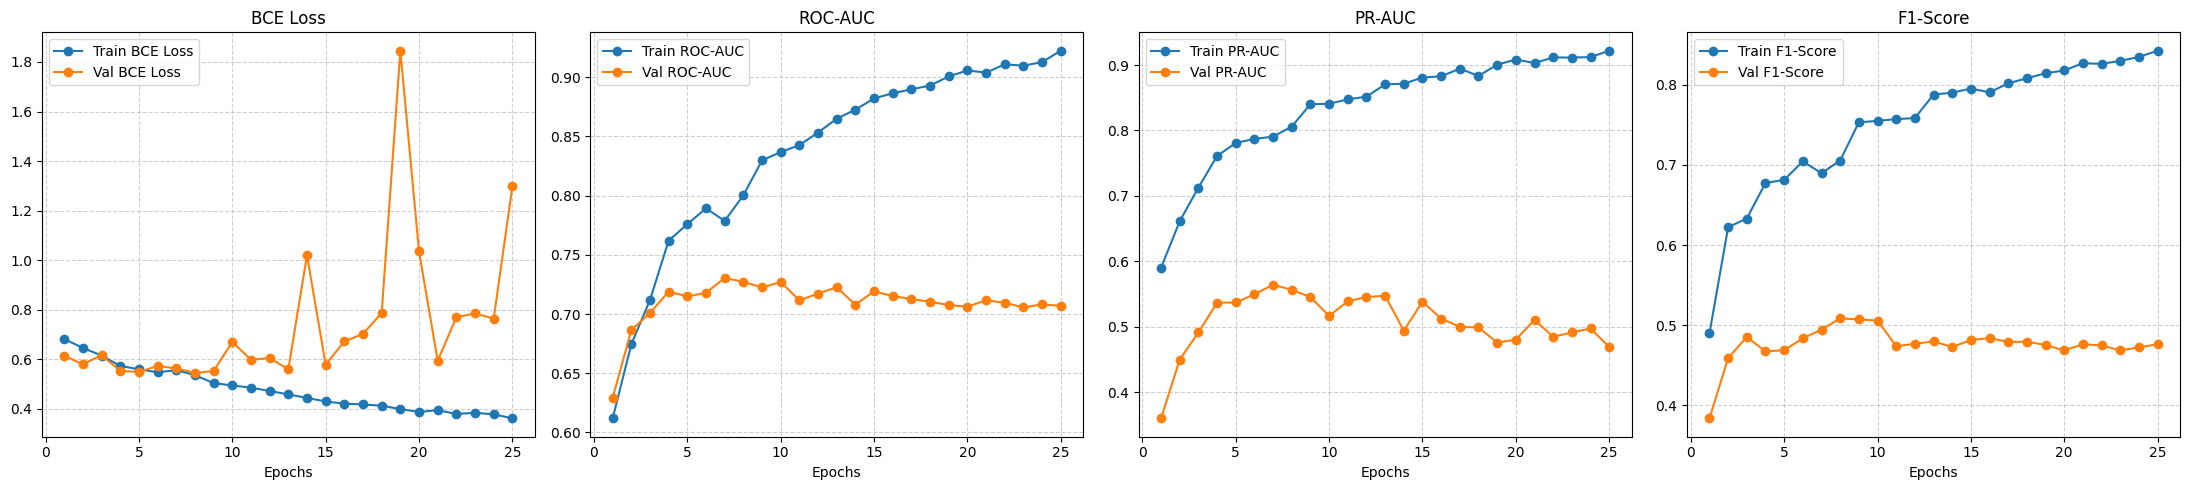


Loading best checkpoint: tribranch_fusion_best.pth

      PER-BRANCH EMBEDDING DIAGNOSTICS (on one val batch)
LiDAR embedding — dim: 2048, mean norm: 13.3290, std: 0.2478
RGB embedding   — dim: 2048, mean norm: 23.5818, std: 0.5757
NIR embedding   — dim: 128, mean norm: 4.9703, std: 0.2041

      FINAL BENCHMARK: UNTOUCHED TEST SET (TRI-BRANCH FUSION)
Optimal Threshold Calibrated on Val : 0.4216

Test Metrics @ Default Threshold (0.50):
  • ROC-AUC     : 0.7239
  • PR-AUC      : 0.5546
  • F1-Score    : 0.4858
  • Precision   : 0.4252
  • Recall      : 0.5664
  • Accuracy    : 0.6913

Test Metrics @ Optimal Calibrated Threshold (0.4216):
  • ROC-AUC     : 0.7239
  • PR-AUC      : 0.5546
  • F1-Score    : 0.5000
  • Precision   : 0.3892
  • Recall      : 0.6991
  • Accuracy    : 0.6401


In [13]:
# !pip install -q rasterio
import os, random, warnings, gc
from pathlib import Path
from typing import Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models
import torchvision.transforms.functional as TF
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    precision_recall_curve
)
import rasterio

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

torch.backends.cudnn.benchmark = True

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════
class CFG:
    ROOT             = Path('/kaggle/input/datasets/shreyansdeshpande/200x200/FINALCNNDATA_200')
    OUTPUT_DIR       = Path('/kaggle/working')
    SATLAS_CKPT_PATH = Path('/kaggle/working/sentinel2_resnet50_si_rgb.pth')

    TRAIN_SITE       = ROOT / 'train' / 'site'
    TRAIN_NOSITE     = ROOT / 'train' / 'no_site'
    VAL_SITE         = ROOT / 'validation' / 'site'
    VAL_NOSITE       = ROOT / 'validation' / 'no_site'
    TEST_SITE        = ROOT / 'test' / 'site'
    TEST_NOSITE      = ROOT / 'test' / 'no_site'

    IMG_SUFFIX       = '.tif'

    # 11-channel layout: 0-3 (Sat: R, G, B, NIR), 4-10 (LiDAR derivatives)
    SAT_BANDS        = [0, 1, 2, 3]
    LIDAR_BANDS      = [4, 5, 6, 7, 8, 9, 10]

    NUM_CLASSES      = 1
    IMG_SIZE         = 200
    SAT_NATIVE_RES   = 20  # Reverses 10x upsampling via area-downsampling to native 10m

    BATCH_SIZE       = 32
    NUM_EPOCHS       = 25
    T_MAX            = NUM_EPOCHS
    ETA_MIN          = 1e-6
    BASE_LR          = 1e-4
    PRETRAIN_LR      = 1e-5  # Conservative LR for pretrained backbone feature extractors
    WEIGHT_DECAY     = 1e-4
    DROPOUT          = 0.3
    SEED             = 42
    NUM_WORKERS      = 2
    USE_AMP          = torch.cuda.is_available()

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.SEED)
CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# DATA INGESTION & DECOUPLED NORMALIZATION PATHWAYS
# ══════════════════════════════════════════════════════════════════════════════
def folder_to_df(site_dir: Path, nosite_dir: Path) -> pd.DataFrame:
    rows = []
    for label, folder in [(1, site_dir), (0, nosite_dir)]:
        files = list(folder.glob(f'*{CFG.IMG_SUFFIX}'))
        for f in sorted(files):
            rows.append({'filepath': str(f), 'label': label})
    return pd.DataFrame(rows, columns=['filepath', 'label'])

print('Scanning dataset folders...')
train_df = folder_to_df(CFG.TRAIN_SITE, CFG.TRAIN_NOSITE)
val_df   = folder_to_df(CFG.VAL_SITE,   CFG.VAL_NOSITE)
test_df  = folder_to_df(CFG.TEST_SITE,  CFG.TEST_NOSITE)

print(f"  Train : {len(train_df):<5} (site: {(train_df['label']==1).sum()}, no_site: {(train_df['label']==0).sum()})")
print(f"  Val   : {len(val_df):<5} (site: {(val_df['label']==1).sum()}, no_site: {(val_df['label']==0).sum()})")
print(f"  Test  : {len(test_df):<5} (site: {(test_df['label']==1).sum()}, no_site: {(test_df['label']==0).sum()})")

def normalize_lidar(lidar_arr: np.ndarray) -> np.ndarray:
    """Per-channel z-score standardization for continuous terrain derivatives."""
    out = np.empty_like(lidar_arr, dtype=np.float32)
    for c in range(lidar_arr.shape[0]):
        ch = lidar_arr[c]
        mean = float(np.nanmean(ch))
        std = float(np.nanstd(ch))
        if std < 1e-4 or np.isnan(std):
            out[c] = ch - mean
        else:
            out[c] = (ch - mean) / (std + 1e-6)
    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)

def normalize_satellite(sat_arr: np.ndarray) -> np.ndarray:
    """
    Fixed [0.0, 1.0] scaling matched to Satlas TCI pretraining.
    If raw L2A surface reflectance (0-10000) is detected, applies a standard
    perceptual gamma stretch to emulate Sentinel-2 True Color Image (TCI) contrast.
    """
    sat_arr = np.nan_to_num(sat_arr, nan=0.0, posinf=0.0, neginf=0.0)
    sat_arr = np.clip(sat_arr, 0.0, None)
    max_val = float(np.max(sat_arr))

    if max_val > 255.0:
        refl = sat_arr / 10000.0
        tci_proxy = np.power(np.clip(refl * 2.5, 0.0, 1.0), 1.0 / 2.2)
        return tci_proxy.astype(np.float32)
    elif max_val > 1.0:
        return (sat_arr / 255.0).astype(np.float32)
    else:
        return sat_arr.astype(np.float32)

def load_multimodal_patch(tif_path: str) -> tuple:
    with rasterio.open(tif_path) as src:
        img = src.read().astype(np.float32)
    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)
    img = np.where((img < -1e4) | (img > 1e4), 0.0, img)

    sat_np = normalize_satellite(img[CFG.SAT_BANDS])
    lidar_np = normalize_lidar(img[CFG.LIDAR_BANDS])
    return sat_np, lidar_np

class MultiModalDataset(Dataset):
    def __init__(self, df: pd.DataFrame, split_name: str, is_train: bool = True):
        self.df = df.reset_index(drop=True)
        self.is_train = is_train

        print(f"Preloading and caching {len(self.df)} {split_name} patches into RAM...")
        self.cached_samples = []
        for _, row in self.df.iterrows():
            sat_np, lidar_np = load_multimodal_patch(row['filepath'])
            self.cached_samples.append((sat_np, lidar_np, float(row['label'])))

    def __len__(self):
        return len(self.cached_samples)

    def _sync_augment(self, t_sat, t_lidar):
        if random.random() > 0.5:
            t_sat = TF.hflip(t_sat)
            t_lidar = TF.hflip(t_lidar)
        if random.random() > 0.5:
            t_sat = TF.vflip(t_sat)
            t_lidar = TF.vflip(t_lidar)
        angle = random.choice([0, 90, 180, 270])
        if angle != 0:
            t_sat = TF.rotate(t_sat, angle)
            t_lidar = TF.rotate(t_lidar, angle)
        return t_sat, t_lidar

    def __getitem__(self, idx):
        sat_np, lidar_np, label = self.cached_samples[idx]

        t_sat = torch.from_numpy(sat_np)
        t_lidar = torch.from_numpy(lidar_np)

        t_sat = TF.resize(t_sat, [CFG.IMG_SIZE, CFG.IMG_SIZE], interpolation=TF.InterpolationMode.BILINEAR, antialias=True)
        t_lidar = TF.resize(t_lidar, [CFG.IMG_SIZE, CFG.IMG_SIZE], interpolation=TF.InterpolationMode.BILINEAR, antialias=True)

        if self.is_train:
            t_sat, t_lidar = self._sync_augment(t_sat, t_lidar)

        return t_sat, t_lidar, torch.tensor(label, dtype=torch.float32)

# ══════════════════════════════════════════════════════════════════════════════
# DATALOADERS
# ══════════════════════════════════════════════════════════════════════════════
class_counts = train_df['label'].value_counts().to_dict()
class_weights = {0: 1.0 / class_counts[0], 1: 1.0 / class_counts[1]}
sample_weights = [class_weights[label] for label in train_df['label']]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(train_df), replacement=True)

trn_loader  = DataLoader(MultiModalDataset(train_df, "Train", is_train=True),
                         batch_size=CFG.BATCH_SIZE, sampler=sampler,
                         num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True)

val_loader  = DataLoader(MultiModalDataset(val_df, "Val", is_train=False),
                         batch_size=CFG.BATCH_SIZE * 2, shuffle=False,
                         num_workers=CFG.NUM_WORKERS, pin_memory=True)

test_loader = DataLoader(MultiModalDataset(test_df, "Test", is_train=False),
                         batch_size=CFG.BATCH_SIZE * 2, shuffle=False,
                         num_workers=CFG.NUM_WORKERS, pin_memory=True)

# ══════════════════════════════════════════════════════════════════════════════
# TRI-BRANCH FUSION ARCHITECTURE
# ══════════════════════════════════════════════════════════════════════════════
class LiDARResNet50Branch(nn.Module):
    def __init__(self, in_channels: int = 7):
        super().__init__()
        weights = models.ResNet50_Weights.IMAGENET1K_V2
        base_model = models.resnet50(weights=weights)

        old_conv = base_model.conv1
        new_conv = nn.Conv2d(
            in_channels=in_channels, out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size, stride=old_conv.stride,
            padding=old_conv.padding, bias=False
        )

        with torch.no_grad():
            mean_weight = old_conv.weight.mean(dim=1, keepdim=True)
            new_conv.weight.copy_(mean_weight.repeat(1, in_channels, 1, 1) * (3.0 / in_channels))

        base_model.conv1 = new_conv
        self.features = nn.Sequential(*list(base_model.children())[:-1])
        self.out_dim = base_model.fc.in_features  # 2048

    def forward(self, x):
        return torch.flatten(self.features(x), 1)

class SatlasRGBBranch(nn.Module):
    def __init__(self, ckpt_path: Optional[Path] = None):
        super().__init__()
        base_model = models.resnet50(weights=None)

        if ckpt_path is not None and Path(ckpt_path).exists():
            print(f"Loading Satlas Sentinel-2 weights from {ckpt_path}...")
            full_state_dict = torch.load(ckpt_path, map_location='cpu')

            target_anchor = "conv1.weight"
            matching_prefix = None
            for key in full_state_dict.keys():
                if key.endswith(target_anchor):
                    matching_prefix = key[:-len(target_anchor)]
                    break

            if matching_prefix is not None:
                print(f"  • Discovered Satlas prefix: '{matching_prefix}'")
                backbone_state_dict = {
                    k[len(matching_prefix):]: v for k, v in full_state_dict.items() if k.startswith(matching_prefix)
                }
            else:
                backbone_state_dict = full_state_dict

            missing, unexpected = base_model.load_state_dict(backbone_state_dict, strict=False)

            allowed_missing = {"fc.weight", "fc.bias"}
            unaccounted_missing = [k for k in missing if k not in allowed_missing]

            if unaccounted_missing:
                raise RuntimeError(
                    f"Satlas checkpoint loading failed critically — {len(unaccounted_missing)} backbone parameters missing!\n"
                    f"Unaccounted missing keys (first 10): {unaccounted_missing[:10]}\n"
                    f"Verify whether prefix resolution ('{matching_prefix}') stripped improperly."
                )

            if unexpected:
                print(f"  ⚠ Notice: {len(unexpected)} unused keys ignored from checkpoint (pretraining heads).")

            print("  ✓ Satlas backbone verified: 100% of convolutional & normalization layers loaded exactly.")
        else:
            print("Notice: Satlas checkpoint not found. Falling back to ImageNet ResNet-50 initialization.")
            base_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        self.features = nn.Sequential(*list(base_model.children())[:-1])
        self.out_dim = base_model.fc.in_features  # 2048

    def forward(self, x):
        return torch.flatten(self.features(x), 1)

class NIRSideBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.out_dim = 128

    def forward(self, x):
        return torch.flatten(self.features(x), 1)

class TriBranchFusionModel(nn.Module):
    def __init__(self, satlas_ckpt: Optional[Path] = None, num_classes: int = 1, dropout: float = 0.3):
        super().__init__()
        self.branch_lidar = LiDARResNet50Branch(in_channels=7)
        self.branch_rgb   = SatlasRGBBranch(ckpt_path=satlas_ckpt)
        self.branch_nir   = NIRSideBranch()

        fused_dim = self.branch_lidar.out_dim + self.branch_rgb.out_dim + self.branch_nir.out_dim

        self.fusion_head = nn.Sequential(
            nn.Linear(fused_dim, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True), nn.Dropout(p=dropout),
            nn.Linear(512, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.Dropout(p=dropout / 2.0),
            nn.Linear(128, num_classes)
        )

    def forward(self, sat_x, lidar_x):
        sat_x_native = F.interpolate(sat_x, size=(CFG.SAT_NATIVE_RES, CFG.SAT_NATIVE_RES), mode='area')

        # Input channels are ordered [Blue, Green, Red, NIR] — reorder first 3 to R,G,B for Satlas
        sat_rgb = sat_x_native[:, [2, 1, 0], :, :]   # index 2=Red, 1=Green, 0=Blue → R,G,B order
        sat_nir = sat_x_native[:, 3:4, :, :]          # NIR unchanged

        emb_lidar = self.branch_lidar(lidar_x)
        emb_rgb   = self.branch_rgb(sat_rgb)
        emb_nir   = self.branch_nir(sat_nir)

        fused = torch.cat([emb_lidar, emb_rgb, emb_nir], dim=1)
        return self.fusion_head(fused)

# ══════════════════════════════════════════════════════════════════════════════
# LOSS FUNCTION & TRAINING ENGINE
# ══════════════════════════════════════════════════════════════════════════════
def build_optimizer(model, base_lr, pretrain_lr):
    new_layer_ids = (
        list(map(id, model.branch_lidar.features[0].parameters())) +
        list(map(id, model.branch_nir.parameters())) +
        list(map(id, model.fusion_head.parameters()))
    )
    pretrained_params = [p for p in model.parameters() if id(p) not in new_layer_ids]
    new_params = [p for p in model.parameters() if id(p) in new_layer_ids]

    return optim.AdamW([
        {'params': pretrained_params, 'lr': pretrain_lr},
        {'params': new_params, 'lr': base_lr}
    ], weight_decay=CFG.WEIGHT_DECAY)

criterion = nn.BCEWithLogitsLoss()

def train_epoch(model, loader, optimizer, scaler):
    model.train()
    total_loss = 0.0
    all_labels, all_preds = [], []

    for sat_b, lidar_b, labels in loader:
        sat_b   = sat_b.to(DEVICE, non_blocking=True)
        lidar_b = lidar_b.to(DEVICE, non_blocking=True)
        labels  = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=CFG.USE_AMP):
            logits = model(sat_b, lidar_b).squeeze(1)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * labels.size(0)
        preds = torch.sigmoid(logits).detach().cpu().numpy()
        all_preds.extend(np.nan_to_num(preds, nan=0.5))
        all_labels.extend(labels.cpu().numpy())

    auc = roc_auc_score(all_labels, all_preds) if len(set(all_labels)) > 1 else 0.0
    pr_auc = average_precision_score(all_labels, all_preds) if len(set(all_labels)) > 1 else 0.0
    bin_preds = [1 if p >= 0.5 else 0 for p in all_preds]
    prec = precision_score(all_labels, bin_preds, zero_division=0)
    rec  = recall_score(all_labels, bin_preds, zero_division=0)
    f1   = f1_score(all_labels, bin_preds, zero_division=0)
    acc  = accuracy_score(all_labels, bin_preds)

    return total_loss / len(loader.dataset), auc, pr_auc, prec, rec, f1, acc

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    all_labels, all_preds = [], []

    for sat_b, lidar_b, labels in loader:
        sat_b   = sat_b.to(DEVICE, non_blocking=True)
        lidar_b = lidar_b.to(DEVICE, non_blocking=True)
        labels  = labels.to(DEVICE, non_blocking=True)

        with torch.amp.autocast(device_type=DEVICE.type, enabled=CFG.USE_AMP):
            logits = model(sat_b, lidar_b).squeeze(1)
            loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        preds = torch.sigmoid(logits).cpu().numpy()
        all_preds.extend(np.nan_to_num(preds, nan=0.5))
        all_labels.extend(labels.cpu().numpy())

    auc = roc_auc_score(all_labels, all_preds) if len(set(all_labels)) > 1 else 0.0
    pr_auc = average_precision_score(all_labels, all_preds) if len(set(all_labels)) > 1 else 0.0
    bin_preds = [1 if p >= 0.5 else 0 for p in all_preds]
    prec = precision_score(all_labels, bin_preds, zero_division=0)
    rec  = recall_score(all_labels, bin_preds, zero_division=0)
    f1   = f1_score(all_labels, bin_preds, zero_division=0)
    acc  = accuracy_score(all_labels, bin_preds)

    return total_loss / len(loader.dataset), auc, pr_auc, prec, rec, f1, acc, all_labels, all_preds

# ══════════════════════════════════════════════════════════════════════════════
# MAIN TRAINING LOOP (25 EPOCHS, NO EARLY STOPPING)
# ══════════════════════════════════════════════════════════════════════════════
model = TriBranchFusionModel(
    satlas_ckpt=CFG.SATLAS_CKPT_PATH,
    num_classes=CFG.NUM_CLASSES,
    dropout=CFG.DROPOUT
).to(DEVICE)

optimizer = build_optimizer(model, base_lr=CFG.BASE_LR, pretrain_lr=CFG.PRETRAIN_LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.T_MAX, eta_min=CFG.ETA_MIN)
scaler    = torch.amp.GradScaler(device=DEVICE.type, enabled=CFG.USE_AMP)

best_val_auc = 0.0
ckpt_path    = CFG.OUTPUT_DIR / 'tribranch_fusion_best.pth'

print(f'\n{"="*75}')
print(f'  Training Tri-Branch Fusion Model (Full {CFG.NUM_EPOCHS} Epochs)')
print(f'{"="*75}')

history = {
    'train_loss':   [], 'train_auc':   [], 'train_pr_auc': [], 'train_f1':   [],
    'val_loss':     [], 'val_auc':     [], 'val_pr_auc':   [], 'val_f1':     []
}

for epoch in range(1, CFG.NUM_EPOCHS + 1):
    trn_loss, trn_auc, trn_pr_auc, trn_prec, trn_rec, trn_f1, trn_acc = train_epoch(model, trn_loader, optimizer, scaler)
    val_loss, val_auc, val_pr_auc, val_prec, val_rec, val_f1, val_acc, _, _ = evaluate(model, val_loader)

    scheduler.step()

    history['train_loss'].append(trn_loss);       history['val_loss'].append(val_loss)
    history['train_auc'].append(trn_auc);         history['val_auc'].append(val_auc)
    history['train_pr_auc'].append(trn_pr_auc);   history['val_pr_auc'].append(val_pr_auc)
    history['train_f1'].append(trn_f1);           history['val_f1'].append(val_f1)

    saved = ''
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), ckpt_path)
        saved = '  ✓ saved'

    print(f'Ep {epoch:02d}/{CFG.NUM_EPOCHS} | LR: {optimizer.param_groups[0]["lr"]:.2e}{saved}')
    print(f'  Train -> Loss: {trn_loss:.4f} | ROC-AUC: {trn_auc:.4f} | PR-AUC: {trn_pr_auc:.4f} | F1: {trn_f1:.4f} | Prec: {trn_prec:.4f} | Rec: {trn_rec:.4f}')
    print(f'  Val   -> Loss: {val_loss:.4f} | ROC-AUC: {val_auc:.4f} | PR-AUC: {val_pr_auc:.4f} | F1: {val_f1:.4f} | Prec: {val_prec:.4f} | Rec: {val_rec:.4f}')

# ══════════════════════════════════════════════════════════════════════════════
# PLOT TRAINING HISTORY
# ══════════════════════════════════════════════════════════════════════════════
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
metrics = [
    ('loss', 'BCE Loss', axes[0]),
    ('auc', 'ROC-AUC', axes[1]),
    ('pr_auc', 'PR-AUC', axes[2]),
    ('f1', 'F1-Score', axes[3])
]

for key, title, ax in metrics:
    ax.plot(epochs, history[f'train_{key}'], label=f'Train {title}', marker='o')
    ax.plot(epochs, history[f'val_{key}'],   label=f'Val {title}',   marker='o')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epochs')
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# TEST SET BENCHMARK
# ══════════════════════════════════════════════════════════════════════════════
if ckpt_path.exists():
    print(f"\nLoading best checkpoint: {ckpt_path.name}")
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()

    print("\n" + "=" * 65)
    print("      PER-BRANCH EMBEDDING DIAGNOSTICS (on one val batch)")
    print("=" * 65)

    sample_sat_b, sample_lidar_b, sample_labels = next(iter(val_loader))
    sample_sat_b = sample_sat_b.to(DEVICE)
    sample_lidar_b = sample_lidar_b.to(DEVICE)

    with torch.no_grad():
        sat_x_native = F.interpolate(sample_sat_b, size=(CFG.SAT_NATIVE_RES, CFG.SAT_NATIVE_RES), mode='area')
        sat_rgb = sat_x_native[:, [2, 1, 0], :, :]
        sat_nir = sat_x_native[:, 3:4, :, :]

        emb_lidar = model.branch_lidar(sample_lidar_b)
        emb_rgb   = model.branch_rgb(sat_rgb)
        emb_nir   = model.branch_nir(sat_nir)

    print(f"LiDAR embedding — dim: {emb_lidar.shape[1]}, mean norm: {emb_lidar.norm(dim=1).mean().item():.4f}, std: {emb_lidar.std().item():.4f}")
    print(f"RGB embedding   — dim: {emb_rgb.shape[1]}, mean norm: {emb_rgb.norm(dim=1).mean().item():.4f}, std: {emb_rgb.std().item():.4f}")
    print(f"NIR embedding   — dim: {emb_nir.shape[1]}, mean norm: {emb_nir.norm(dim=1).mean().item():.4f}, std: {emb_nir.std().item():.4f}")
    print("=" * 65)

    # Threshold calibration on Validation set
    _, val_auc, val_pr_auc, _, _, _, _, val_labels, val_preds = evaluate(model, val_loader)
    precisions, recalls, thresholds = precision_recall_curve(val_labels, val_preds)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_thresh = float(thresholds[best_idx])

    # Final evaluation on untouched Test set
    tst_loss, tst_auc, tst_pr_auc, _, _, _, _, test_labels, test_preds = evaluate(model, test_loader)
    test_preds_np  = np.array(test_preds)
    test_labels_np = np.array(test_labels)

    bin_default = (test_preds_np >= 0.5).astype(int)
    bin_opt     = (test_preds_np >= best_thresh).astype(int)

    print("\n" + "=" * 65)
    print("      FINAL BENCHMARK: UNTOUCHED TEST SET (TRI-BRANCH FUSION)")
    print("=" * 65)
    print(f"Optimal Threshold Calibrated on Val : {best_thresh:.4f}")
    print(f"\nTest Metrics @ Default Threshold (0.50):")
    print(f"  • ROC-AUC     : {tst_auc:.4f}")
    print(f"  • PR-AUC      : {tst_pr_auc:.4f}")
    print(f"  • F1-Score    : {f1_score(test_labels_np, bin_default, zero_division=0):.4f}")
    print(f"  • Precision   : {precision_score(test_labels_np, bin_default, zero_division=0):.4f}")
    print(f"  • Recall      : {recall_score(test_labels_np, bin_default, zero_division=0):.4f}")
    print(f"  • Accuracy    : {accuracy_score(test_labels_np, bin_default):.4f}")

    print(f"\nTest Metrics @ Optimal Calibrated Threshold ({best_thresh:.4f}):")
    print(f"  • ROC-AUC     : {tst_auc:.4f}")
    print(f"  • PR-AUC      : {tst_pr_auc:.4f}")
    print(f"  • F1-Score    : {f1_score(test_labels_np, bin_opt, zero_division=0):.4f}")
    print(f"  • Precision   : {precision_score(test_labels_np, bin_opt, zero_division=0):.4f}")
    print(f"  • Recall      : {recall_score(test_labels_np, bin_opt, zero_division=0):.4f}")
    print(f"  • Accuracy    : {accuracy_score(test_labels_np, bin_opt):.4f}")
    print("=" * 65)

gc.collect()
torch.cuda.empty_cache()

In [12]:
from pathlib import Path

# Check what CFG actually has
print("CFG.SATLAS_CKPT_PATH:", CFG.SATLAS_CKPT_PATH)
print("Exists?", CFG.SATLAS_CKPT_PATH.exists())

# Check what's actually in /kaggle/working
import os
print("\nFiles in /kaggle/working:")
for f in os.listdir('/kaggle/working'):
    print(" ", f)

CFG.SATLAS_CKPT_PATH: /kaggle/working/sentinel2_resnet50_si_rgb.pth
Exists? True

Files in /kaggle/working:
  confusion_matrix_train.png
  model_20260808_144823.pth
  confusion_matrix_val.png
  model_code_20260814_110103.py
  threshold_metrics.png
  model_20260808_181408.pth
  submission_tta.csv
  model_20260808_194413.pth
  .virtual_documents
  torchgeo_resnet18_best.pth
  model_code_20260808_144823.py
  model_code_20260808_201556.py
  model_20260808_171406.pth
  model_code_20260808_181408.py
  confusion_matrix_050.png
  densenet121_pretrained_best.pth
  efficientnet_b0_best.pth
  model_code_20260808_194413.py
  model_20260808_195109.pth
  spatial_heatmap_train.png
  model_20260808_201556.pth
  densenet121_lidar_best.pth
  learning_curve_results
  model_code_20260808_192725.py
  efficientnet_b0_lidar_aux_best.pth
  learning_curve_5fold_results
  FINALCNNDATA_200
  model_20260814_110103.pth
  model_20260814_101139.pth
  confusion_matrix_best_threshold.png
  model_code_20260808_171406.p

In [9]:
import torch
from pathlib import Path
import torchvision.models as models

ckpt_path = Path('/kaggle/working/sentinel2_resnet50_si_rgb.pth')
base_model = models.resnet50(weights=None)

full_state_dict = torch.load(ckpt_path, map_location='cpu')

target_anchor = "conv1.weight"
matching_prefix = None
for key in full_state_dict.keys():
    if key.endswith(target_anchor):
        matching_prefix = key[:-len(target_anchor)]
        break

print("Discovered prefix:", matching_prefix)

backbone_state_dict = {
    k[len(matching_prefix):]: v for k, v in full_state_dict.items() if k.startswith(matching_prefix)
}

missing, unexpected = base_model.load_state_dict(backbone_state_dict, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

Discovered prefix: backbone.resnet.
Missing keys: []
Unexpected keys: []
